In [11]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [2]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


In [29]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return -self + other

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "Only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += out.grad * other * (self.data**(other-1))
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) -1)/(math.exp(2*x)+1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)

                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0

        for node in reversed(topo):
            node._backward()

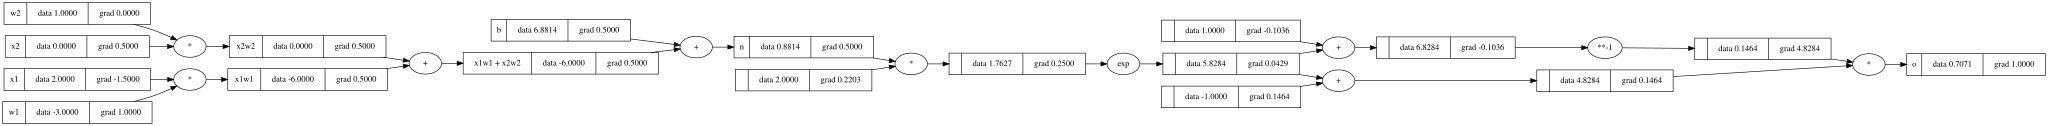

In [30]:
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'

x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'

n = x1w1x2w2 + b; n.label = 'n'

# o = n.tanh(); o.label = 'o'
e = (2*n).exp()
o = (e-1) / (e+1)

o.label = 'o'

o.backward()

draw_dot(o)

In [31]:
import torch

x1 = torch.Tensor([2.0]).double();   x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();   x2.requires_grad = True

w1 = torch.Tensor([-3.0]).double();   w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();    w2.requires_grad = True

b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1*w1 + x2*w2 + b

o = torch.tanh(n)
o.backward()

print(o.data.item())

print("=======")

print('x2', x2.grad.item())
print('x1', x1.grad.item())
print('w2', w2.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
x2 0.5000001283844369
x1 -1.5000003851533106
w2 0.0
w1 1.0000002567688737


In [48]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x, *args, **kwds):
        act = sum((xi*wi for xi,wi in zip(x, self.w)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x, *args, **kwds):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x, *args, **kwds):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

Value(data=-0.8817335788019438)

In [207]:
n = MLP(3, [4,4,1])

xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0]

In [208]:
n_iter = 1000
learning_rate = 0.1

for ni in range(n_iter):
    ypred = [n(x) for x in xs]
    loss = sum((ys[i] - ypred[i])**2 for i in range(len(ys)))
    if (ni+1)%100 == 0:
        print(ni+1, loss)

    for p in n.parameters():
        p.grad = 0
    loss.backward()

    for p in n.parameters():
        p.data += -p.grad * learning_rate


100 Value(data=0.0030045802186319677)
200 Value(data=0.0013681831395370933)
300 Value(data=0.0008745072524177065)
400 Value(data=0.0006388001720167777)
500 Value(data=0.0005014252244829312)
600 Value(data=0.00041173246129744376)
700 Value(data=0.0003486911241644561)
800 Value(data=0.0003020243596478431)
900 Value(data=0.00026612362614752993)
1000 Value(data=0.0002376721252803557)


In [209]:
ypred

[Value(data=0.9922327764486243),
 Value(data=-0.9919043518341344),
 Value(data=-0.9919241839750969),
 Value(data=0.9931747498295121)]

In [178]:
n.parameters()

[Value(data=1.3688050630893775),
 Value(data=-2.126284129780067),
 Value(data=-0.5526198065322566),
 Value(data=-1.7887907044331661),
 Value(data=3.630801481688268),
 Value(data=-5.583626929536037),
 Value(data=5.097012955381282),
 Value(data=0.09854245456108773),
 Value(data=1.7339066459041201),
 Value(data=1.936066041582881),
 Value(data=-0.40511505846541745),
 Value(data=1.329912413069041),
 Value(data=1.4720659831060228),
 Value(data=8.088960397523204),
 Value(data=-12.25862139865283),
 Value(data=2.102141023745156),
 Value(data=0.7418934455517334),
 Value(data=0.5593836506094257),
 Value(data=0.9662773414132344),
 Value(data=-0.8571946117298465),
 Value(data=0.9937988501728574),
 Value(data=0.33822912158768825),
 Value(data=-0.9481317788807654),
 Value(data=1.3275987193365506),
 Value(data=0.7183046156818865),
 Value(data=0.3456876117226264),
 Value(data=-2.147597289447682),
 Value(data=-7.152154295229303),
 Value(data=-5.053150544181111),
 Value(data=13.026907419817391),
 Value(d